<h1>Z-Distribution</h1>

Compas,Gabriel Zion T09

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df =pd.read_csv(r'dataset\transformer-voltage.csv', delimiter=',', index_col='Sample')
df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [5]:
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [8]:
alpha = 0.01
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(2.5758293035489004)

In [20]:
pop_std = 5
ci_lower,ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)
print(f'Ci = [{ci_lower:.2f},{ci_upper:.2f}]')

Ci = [118.50,122.08]


<function matplotlib.pyplot.show(close=None, block=None)>

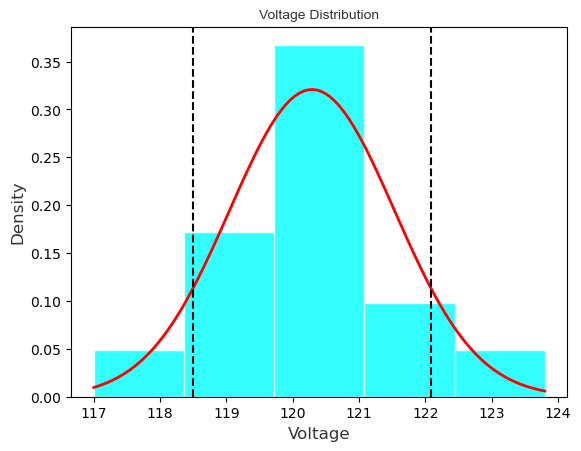

In [29]:
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

x = np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p, 'red', linewidth=2)
plt.hist(df['Voltage'], bins=5,
        density=True,
        alpha=0.8,
        color= 'aqua',
        edgecolor='white',)


plt.title('Voltage Distribution', fontsize=14, font='Arial', color='#333333')
plt.xlabel('Voltage', fontsize=12, color='#333333')
plt.ylabel('Density', fontsize=12, color='#333333')

plt.axvline(x=ci_lower,
        color = 'black',
        linestyle = '--')
plt.axvline(x=ci_upper,
        color = 'black',
        linestyle = '--')
plt.show